In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('DataSets/sales_data_sample.csv',encoding='unicode_escape')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [7]:
df.shape

(2823, 14)

In [8]:
df.describe

<bound method NDFrame.describe of       QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES        ORDERDATE  \
0                  30      95.70                2  2871.00   2/24/2003 0:00   
1                  34      81.35                5  2765.90    5/7/2003 0:00   
2                  41      94.74                2  3884.34    7/1/2003 0:00   
3                  45      83.26                6  3746.70   8/25/2003 0:00   
4                  49     100.00               14  5205.27  10/10/2003 0:00   
...               ...        ...              ...      ...              ...   
2818               20     100.00               15  2244.40   12/2/2004 0:00   
2819               29     100.00                1  3978.51   1/31/2005 0:00   
2820               43     100.00                4  5417.57    3/1/2005 0:00   
2821               34      62.24                1  2116.16   3/28/2005 0:00   
2822               47      65.52                9  3079.44    5/6/2005 0:00   

        STATUS  Q

In [10]:
df.isnull().sum()

QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
STATUS             0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
COUNTRY            0
DEALSIZE           0
dtype: int64

In [11]:
df.drop(columns=['ORDERDATE','STATUS','MONTH_ID','QTR_ID','YEAR_ID'],inplace=True)
df.head()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,Motorcycles,95,S10_1678,USA,Small
1,34,81.35,5,2765.90,Motorcycles,95,S10_1678,France,Small
2,41,94.74,2,3884.34,Motorcycles,95,S10_1678,France,Medium
3,45,83.26,6,3746.70,Motorcycles,95,S10_1678,USA,Medium
4,49,100.00,14,5205.27,Motorcycles,95,S10_1678,USA,Medium


In [12]:
from sklearn.preprocessing import LabelEncoder
def convert_categories(col):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].values)

In [13]:
categories = ['PRODUCTLINE','PRODUCTCODE','COUNTRY','DEALSIZE']
for col in categories:
    convert_categories(col)

In [14]:
df.head()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,1,95,0,18,2
1,34,81.35,5,2765.90,1,95,0,6,2
2,41,94.74,2,3884.34,1,95,0,6,1
3,45,83.26,6,3746.70,1,95,0,18,1
4,49,100.00,14,5205.27,1,95,0,18,1


In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
data = sc.fit_transform(df)

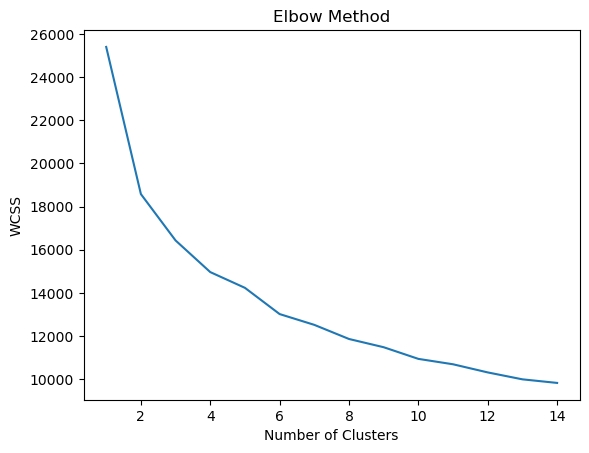

In [19]:
plt.plot(range(1, 15), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [20]:
x_train = df.values

In [21]:
x_train.shape

(2823, 9)

In [22]:
model = KMeans (n_clusters=3, random_state=2)
model = model.fit(x_train)
predictions = model.predict(x_train)

In [23]:
unique, counts = np.unique(predictions, return_counts=True)

In [24]:
counts = counts.reshape(1,3)

In [26]:
counts_df = pd.DataFrame(counts, columns=['Cluster', 'Cluster2', 'Cluster3'])

In [27]:
counts_df.head()

,Cluster,Cluster2,Cluster3
0,1344,398,1081


In [29]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_X = pd.DataFrame(pca.fit_transform(x_train), columns=['РСА1', 'РЕA2'])
reduced_X.head()

,РСА1,РЕA2
0,-682.487613,42.820560
1,-787.665626,41.738004
2,330.732009,26.515880
3,193.040995,26.269605
4,1651.533634,6.867827
